## 0. Setup

In [1]:
from pathlib import Path
import sys, math, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)


def find_project_root(start=Path.cwd()):
    """Find the project folder that directly contains datasets/ and eda_tools.py."""
    start = start.resolve()
    candidates = [start, *start.parents]

    for p in candidates:
        if (p / "datasets").is_dir() and (p / "eda_tools.py").is_file():
            return p

    raise FileNotFoundError(
        f"Could not find a project folder containing datasets/ and eda_tools.py starting from: {start}"
    )


PROJECT_ROOT = find_project_root()
DATASETS_ROOT = (PROJECT_ROOT / "datasets").resolve()

# eda_tools.Study intentionally requires its output to be outside the source root.
# Keep the generated results next to the project folder so the source inventory stays clean.
OUTPUT_ROOT = (PROJECT_ROOT.parent / f"{PROJECT_ROOT.name}_results").resolve()
FIGURE_ROOT = OUTPUT_ROOT / "figures"

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATASETS_ROOT:", DATASETS_ROOT)
print("OUTPUT_ROOT  :", OUTPUT_ROOT)
print("FIGURE_ROOT  :", FIGURE_ROOT)


PROJECT_ROOT : C:\Users\liang\OneDrive\Desktop\openlintim
DATASETS_ROOT: C:\Users\liang\OneDrive\Desktop\openlintim\datasets
OUTPUT_ROOT  : C:\Users\liang\OneDrive\Desktop\openlintim_results
FIGURE_ROOT  : C:\Users\liang\OneDrive\Desktop\openlintim_results\figures


## 1. Understand the repository

In [2]:
folder_purposes = pd.DataFrame([
    ["datasets/", "Research datasets and example instances", "YES — main EDA source"],
    ["datasets/<dataset>/basis/", "Core input data: stops, edges, OD demand, loads, configuration, infrastructure", "YES — primary inputs"],
    ["datasets/<dataset>/line-planning/", "Line concepts or line-planning outputs/inputs", "Conditional"],
    ["datasets/<dataset>/timetabling/", "Periodic events, activities and timetables when present", "Conditional"],
    ["datasets/<dataset>/delay-management/", "Delay-management inputs/outputs when present", "Conditional"],
    ["datasets/<dataset>/vehicle-scheduling/", "Vehicle scheduling inputs/outputs when present", "Conditional"],
    ["datasets/<dataset>/tariff/", "Tariff-related files when present", "Conditional"],
    ["datasets/<dataset>/graphics/", "Visualization/build files", "NO — not observations"],
    ["src/", "OpenLinTim algorithm and application source code", "NO"],
    ["ci/", "Continuous-integration tests and synthetic test fixtures", "NO — excluded from study sample"],
    ["doc/", "Documentation and format descriptions", "Reference only"],
    ["libs/", "Library/build support", "NO"],
    ["docker/", "Container definitions", "NO"],
], columns=["folder", "purpose", "role_in_this_eda"])
display(folder_purposes)

,folder,purpose,role_in_this_eda
0,datasets/,Research datasets and example instances,YES — main EDA source
1,datasets/<dataset>/basis/,"Core input data: stops, edges, OD demand, loads, configuration, infrastructure",YES — primary inputs
2,datasets/<dataset>/line-planning/,Line concepts or line-planning outputs/inputs,Conditional
3,datasets/<dataset>/timetabling/,"Periodic events, activities and timetables when present",Conditional
4,datasets/<dataset>/delay-management/,Delay-management inputs/outputs when present,Conditional
5,datasets/<dataset>/vehicle-scheduling/,Vehicle scheduling inputs/outputs when present,Conditional
6,datasets/<dataset>/tariff/,Tariff-related files when present,Conditional
7,datasets/<dataset>/graphics/,Visualization/build files,NO — not observations
8,src/,OpenLinTim algorithm and application source code,NO
9,ci/,Continuous-integration tests and synthetic test fixtures,NO — excluded from study sample


In [3]:
purpose_by_name = {
    "datasets": "research datasets",
    "basis": "core dataset inputs",
    "line-planning": "line planning",
    "timetabling": "timetabling",
    "delay-management": "delay management",
    "vehicle-scheduling": "vehicle scheduling",
    "tariff": "tariff data",
    "graphics": "graphics/build support",
    "src": "source code — excluded",
    "ci": "test fixtures — excluded",
    "doc": "documentation",
    "libs": "libraries/build support",
    "docker": "container setup",
}

dirs = [PROJECT_ROOT] + sorted([p for p in PROJECT_ROOT.rglob("*") if p.is_dir()])
lines=[]
for p in dirs:
    rel = "." if p == PROJECT_ROOT else p.relative_to(PROJECT_ROOT).as_posix()
    depth = 0 if p == PROJECT_ROOT else len(p.relative_to(PROJECT_ROOT).parts)
    label = purpose_by_name.get(p.name, "")
    lines.append("    " * depth + rel.split("/")[-1] + "/" + (f"   # {label}" if label else ""))

directory_tree_text = "\n".join(lines)
(OUTPUT_ROOT / "directory_tree_full.txt").write_text(directory_tree_text, encoding="utf-8")
display(HTML(f'<pre style="max-height:620px;overflow:auto;border:1px solid #ddd;padding:10px">{directory_tree_text}</pre>'))
print(f"Directories shown: {len(dirs):,}")

Directories shown: 916


### 1.2 reusable path

In [4]:
def classify_stage(dataset_relative_parts):
    if len(dataset_relative_parts) == 1:
        return "datasets-root"
    if len(dataset_relative_parts) == 2:
        return "dataset-root"
    return dataset_relative_parts[1]

def classify_file(name):
    known = [
        "Infrastructure-Link.giv", "Infrastructure-Node.giv", "Infrastructure-OD.giv",
        "Existing-Stop.giv", "Existing-Edge.giv", "Pool-Cost.giv", "Line-Concept.lin",
        "PTN-Infrastructure-Map.giv", "Stop.giv.geo", "Demand.giv.geo", "Stop.giv",
        "Edge.giv", "OD.giv", "Load.giv", "Headway.giv", "Pool.giv", "Demand.giv",
        "Config.cnf", "Makefile"
    ]
    for k in known:
        if name == k or name.endswith("." + k):
            return k
    return Path(name).suffix.lstrip(".") or "other"

rows=[]
for p in sorted(DATASETS_ROOT.rglob("*")):
    if not p.is_file():
        continue
    rel_project = p.relative_to(PROJECT_ROOT)
    rel_ds = p.relative_to(DATASETS_ROOT)
    parts = rel_ds.parts
    rows.append({
        "relative_path": rel_project.as_posix(),
        "absolute_path": str(p.resolve()),
        "dataset": parts[0] if len(parts) > 1 else "(datasets root)",
        "stage": classify_stage(parts),
        "file_type": classify_file(p.name),
        "size_kb": round(p.stat().st_size / 1024, 2),
    })

data_file_registry = pd.DataFrame(rows)
data_file_registry.to_csv(OUTPUT_ROOT / "data_file_registry.csv", index=False)
html = data_file_registry.to_html(index=False, escape=True)
display(HTML(f'<div style="max-height:620px;overflow:auto;border:1px solid #ddd">{html}</div>'))
print(f"Dataset files shown: {len(data_file_registry):,}")

relative_path,absolute_path,dataset,stage,file_type,size_kb
datasets/.gitignore,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\.gitignore,(datasets root),datasets-root,other,0.12
datasets/athens/basis/Config.cnf,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Config.cnf,athens,basis,Config.cnf,2.32
datasets/athens/basis/Edge.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Edge.giv,athens,basis,Edge.giv,1.50
datasets/athens/basis/Headway.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Headway.giv,athens,basis,Headway.giv,0.33
datasets/athens/basis/Load.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Load.giv,athens,basis,Load.giv,0.87
datasets/athens/basis/OD.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\OD.giv,athens,basis,OD.giv,26.24
datasets/athens/basis/Pool-Cost.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Pool-Cost.giv,athens,basis,Pool-Cost.giv,0.93
datasets/athens/basis/Pool.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Pool.giv,athens,basis,Pool.giv,6.08
datasets/athens/basis/Stop.giv,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Stop.giv,athens,basis,Stop.giv,3.70
datasets/athens/basis/Stop.giv.geo,C:\Users\liang\OneDrive\Desktop\openlintim\datasets\athens\basis\Stop.giv.geo,athens,basis,Stop.giv.geo,1.18


Dataset files shown: 284


### 1.3 What the recurring file types mean

In [5]:
file_type_purposes = pd.DataFrame([
    ["Stop.giv", "Public transport stops/nodes used by a PTN view"],
    ["Edge.giv", "PTN edges: endpoints, length, lower and upper travel-time bounds"],
    ["OD.giv", "Origin-destination demand between stops"],
    ["Load.giv", "Edge load plus lower/upper line-frequency constraints"],
    ["Headway.giv", "Headway constraints by edge"],
    ["Pool.giv", "Candidate line pool expressed as ordered edge sequences"],
    ["Pool-Cost.giv", "Candidate line length/cost"],
    ["Infrastructure-Node.giv", "Underlying multimodal infrastructure nodes"],
    ["Infrastructure-Link.giv", "Infrastructure links with length, capacity and allowed modalities"],
    ["PTN-Infrastructure-Map.giv", "Mapping from PTN edges to infrastructure links"],
    ["Demand.giv", "Demand points used by infrastructure/stop-location datasets"],
    ["Config.cnf", "Dataset-specific settings; may include and override global settings"],
], columns=["file_type", "meaning"])
display(file_type_purposes)

,file_type,meaning
0,Stop.giv,Public transport stops/nodes used by a PTN view
1,Edge.giv,"PTN edges: endpoints, length, lower and upper travel-time bounds"
2,OD.giv,Origin-destination demand between stops
3,Load.giv,Edge load plus lower/upper line-frequency constraints
4,Headway.giv,Headway constraints by edge
5,Pool.giv,Candidate line pool expressed as ordered edge sequences
6,Pool-Cost.giv,Candidate line length/cost
7,Infrastructure-Node.giv,Underlying multimodal infrastructure nodes
8,Infrastructure-Link.giv,"Infrastructure links with length, capacity and allowed modalities"
9,PTN-Infrastructure-Map.giv,Mapping from PTN edges to infrastructure links


## 2. Data process

In [6]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from eda_tools import Study

study = Study(PROJECT_ROOT, OUTPUT_ROOT, seed=42)
study.inventory()
study.profile()
study.build_views()
study.analyze()
study.multimodal()
study.finish_audit()

TABLE_ROOT = OUTPUT_ROOT / "tables"
network_summary = pd.read_csv(TABLE_ROOT / "network_summary.csv")
view_registry = pd.read_csv(TABLE_ROOT / "view_registry.csv")
table_profile = pd.read_csv(TABLE_ROOT / "table_profile.csv")
column_profile = pd.read_csv(TABLE_ROOT / "column_profile.csv")
quality_issues = pd.read_csv(TABLE_ROOT / "quality_issues.csv")
edges = pd.read_csv(TABLE_ROOT / "edges_enriched.csv")
edge_loads = pd.read_csv(TABLE_ROOT / "edge_loads.csv")
od_summary = pd.read_csv(TABLE_ROOT / "od_summary.csv")

print(f"Analyzable datasets: {network_summary['dataset'].nunique()}")
print(f"Network views:       {len(network_summary)}")
print(f"Parsed data tables:  {len(table_profile)}")
print(f"PTN edge records:    {len(edges):,}")

Analyzable datasets: 15
Network views:       27
Parsed data tables:  148
PTN edge records:    36,201


### 2.1 Exact files

In [7]:
display(view_registry[["view", "dataset", "modality", "network_type", "directed", "stop_path", "edge_path", "OD_giv_path", "Load_giv_path"]].fillna(""))

,view,dataset,modality,network_type,directed,stop_path,edge_path,OD_giv_path,Load_giv_path
0,athens/default,athens,default,ptn,False,datasets/athens/basis/Stop.giv,datasets/athens/basis/Edge.giv,datasets/athens/basis/OD.giv,datasets/athens/basis/Load.giv
1,BOMHarbour/default,BOMHarbour,default,ptn,False,datasets/BOMHarbour/basis/Stop.giv,datasets/BOMHarbour/basis/Edge.giv,datasets/BOMHarbour/basis/OD.giv,datasets/BOMHarbour/basis/Load.giv
2,goevb/default,goevb,default,ptn,True,datasets/goevb/basis/Stop.giv,datasets/goevb/basis/Edge.giv,datasets/goevb/basis/OD.giv,datasets/goevb/basis/Load.giv
3,grid/default,grid,default,ptn,False,datasets/grid/basis/Stop.giv,datasets/grid/basis/Edge.giv,datasets/grid/basis/OD.giv,datasets/grid/basis/Load.giv
4,grid-multimodal/bike,grid-multimodal,bike,ptn,False,datasets/grid-multimodal/basis/bike.Stop.giv,datasets/grid-multimodal/basis/bike.Edge.giv,datasets/grid-multimodal/basis/bike.OD.giv,datasets/grid-multimodal/basis/bike.Load.giv
5,grid-multimodal/bus,grid-multimodal,bus,ptn,False,datasets/grid-multimodal/basis/bus.Stop.giv,datasets/grid-multimodal/basis/bus.Edge.giv,datasets/grid-multimodal/basis/bus.OD.giv,datasets/grid-multimodal/basis/bus.Load.giv
6,grid-multimodal/joint,grid-multimodal,joint,ptn,False,datasets/grid-multimodal/basis/joint.Stop.giv,datasets/grid-multimodal/basis/joint.Edge.giv,datasets/grid-multimodal/basis/joint.OD.giv,
7,grid-multimodal/tram,grid-multimodal,tram,ptn,False,datasets/grid-multimodal/basis/tram.Stop.giv,datasets/grid-multimodal/basis/tram.Edge.giv,datasets/grid-multimodal/basis/tram.OD.giv,datasets/grid-multimodal/basis/tram.Load.giv
8,helsinki/bus,helsinki,bus,ptn,True,datasets/helsinki/basis/bus.Stop.giv,datasets/helsinki/basis/bus.Edge.giv,,
9,helsinki/ferry,helsinki,ferry,ptn,True,datasets/helsinki/basis/ferry.Stop.giv,datasets/helsinki/basis/ferry.Edge.giv,,


## 3. Validate — data quality and availability come before plots

Two kinds of missingness are separated:

1. **Cell-level missingness:** a file exists but some values are blank.
2. **Structural availability:** a dataset simply does not provide a certain file type.

The second is especially important here because not every OpenLinTim example contains OD, load, line-pool, or infrastructure-capacity data.

In [8]:
quality_overview = pd.DataFrame({
    "metric": ["Parsed tables", "Rows with parse errors", "Duplicate data rows", "Missing cells"],
    "value": [len(table_profile), int(table_profile.bad_rows.sum()), int(table_profile.duplicate_rows.sum()), int(table_profile.missing_cells.sum())]
})
display(quality_overview)

missing_columns = column_profile[column_profile["missing"] > 0][["path", "column", "rows", "missing", "unique"]]
print("Columns with cell-level missingness:")
display(missing_columns if len(missing_columns) else pd.DataFrame({"result": ["None"]}))

print("Semantic / cross-file quality warnings:")
display(quality_issues if len(quality_issues) else pd.DataFrame({"result": ["None"]}))

,metric,value
0,Parsed tables,148
1,Rows with parse errors,0
2,Duplicate data rows,0
3,Missing cells,229


Columns with cell-level missingness:


,path,column,rows,missing,unique
239,datasets/helsinki/basis/Demand.giv,short_name,1092,229,861


Semantic / cross-file quality warnings:


,scope,check,count,severity,detail
0,helsinki,shared_id_coordinate_disagreement,63,warning,bus vs tram
1,helsinki,shared_id_coordinate_disagreement,9,warning,bus vs rail
2,helsinki,shared_id_coordinate_disagreement,7,warning,bus vs subway
3,helsinki,shared_id_coordinate_disagreement,10,warning,bus vs walk
4,helsinki,shared_id_coordinate_disagreement,57,warning,tram vs walk
5,helsinki,shared_id_coordinate_disagreement,6,warning,rail vs walk
6,helsinki,shared_id_coordinate_disagreement,1,warning,subway vs tram
7,helsinki,shared_id_coordinate_disagreement,6,warning,subway vs walk
8,helsinki,shared_id_coordinate_disagreement,1,warning,ferry vs tram
9,helsinki,shared_id_coordinate_disagreement,1,warning,ferry vs walk


### Figure 1 — data availability

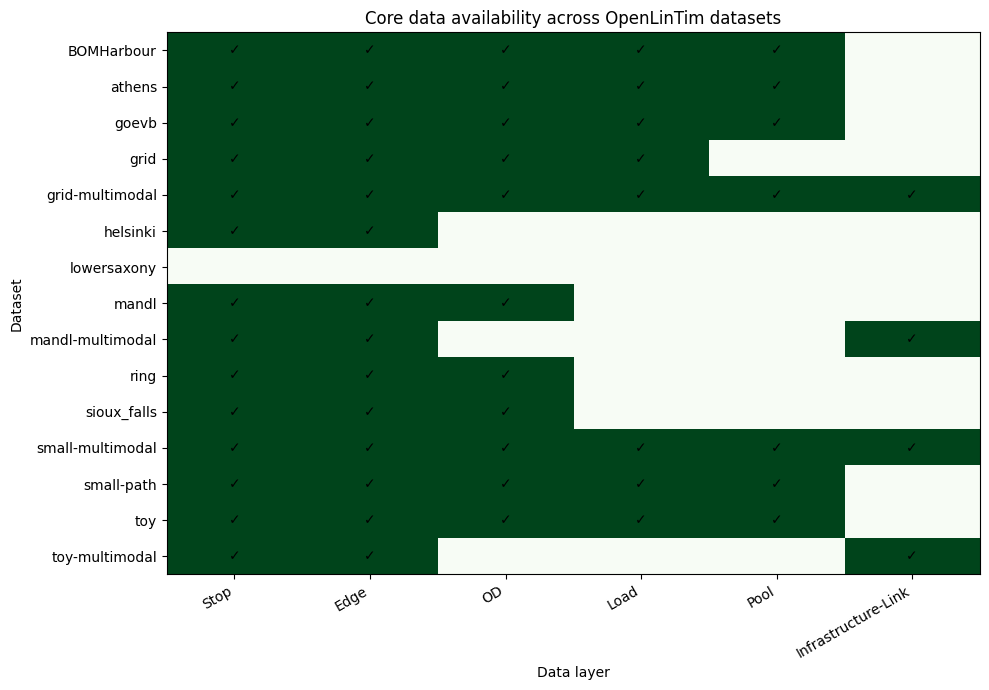

In [9]:
core_types = ["Stop.giv", "Edge.giv", "OD.giv", "Load.giv", "Pool.giv", "Infrastructure-Link.giv"]
profile_present = table_profile.assign(present=1).pivot_table(index="dataset", columns="kind", values="present", aggfunc="max", fill_value=0)
availability = profile_present.reindex(columns=core_types, fill_value=0).sort_index()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(availability.values, aspect="auto", vmin=0, vmax=1, cmap="Greens")
ax.set_xticks(range(len(core_types)), [x.replace(".giv", "") for x in core_types], rotation=30, ha="right")
ax.set_yticks(range(len(availability)), availability.index)
for i in range(availability.shape[0]):
    for j in range(availability.shape[1]):
        ax.text(j, i, "✓" if availability.iloc[i, j] else "", ha="center", va="center", fontsize=10)
ax.set_title("Core data availability across OpenLinTim datasets")
ax.set_xlabel("Data layer")
ax.set_ylabel("Dataset")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "01_core_data_availability.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Describe and compare

In [10]:
network_table = network_summary[[
    "view", "directed", "stops", "edge_records", "weak_components", "isolates",
    "largest_component_share", "mean_out_degree", "simple_density", "length_km",
    "stop_source", "edge_source"
]].sort_values("edge_records", ascending=False)
display(network_table)

,view,directed,stops,edge_records,weak_components,isolates,largest_component_share,mean_out_degree,simple_density,length_km,stop_source,edge_source
13,helsinki/walk,True,3510,26698,34,15,0.932194,7.606268,0.002168,17984.243080,datasets/helsinki/basis/walk.Stop.giv,datasets/helsinki/basis/walk.Edge.giv
8,helsinki/bus,True,3419,7768,3,0,0.998830,2.272009,0.000665,3698.163420,datasets/helsinki/basis/bus.Stop.giv,datasets/helsinki/basis/bus.Edge.giv
2,goevb/default,True,257,548,1,0,1.000000,2.132296,0.008329,245.713620,datasets/goevb/basis/Stop.giv,datasets/goevb/basis/Edge.giv
18,ring/default,False,161,320,1,0,1.000000,3.975155,0.024845,256.000000,datasets/ring/basis/Stop.giv,datasets/ring/basis/Edge.giv
12,helsinki/tram,True,132,281,1,0,1.000000,2.128788,0.016250,88.223170,datasets/helsinki/basis/tram.Stop.giv,datasets/helsinki/basis/tram.Edge.giv
10,helsinki/rail,True,44,110,1,0,1.000000,2.500000,0.058140,355.633500,datasets/helsinki/basis/rail.Stop.giv,datasets/helsinki/basis/rail.Edge.giv
6,grid-multimodal/joint,False,25,79,1,0,1.000000,3.200000,0.133333,278.000000,datasets/grid-multimodal/basis/joint.Stop.giv,datasets/grid-multimodal/basis/joint.Edge.giv
0,athens/default,False,51,52,1,0,1.000000,2.039216,0.040784,73.588130,datasets/athens/basis/Stop.giv,datasets/athens/basis/Edge.giv
4,grid-multimodal/bike,False,25,40,1,0,1.000000,3.200000,0.133333,200.000000,datasets/grid-multimodal/basis/bike.Stop.giv,datasets/grid-multimodal/basis/bike.Edge.giv
3,grid/default,False,25,40,1,0,1.000000,3.200000,0.133333,80.000000,datasets/grid/basis/Stop.giv,datasets/grid/basis/Edge.giv


### Figure 2 — Network scale: number of stops and edge records

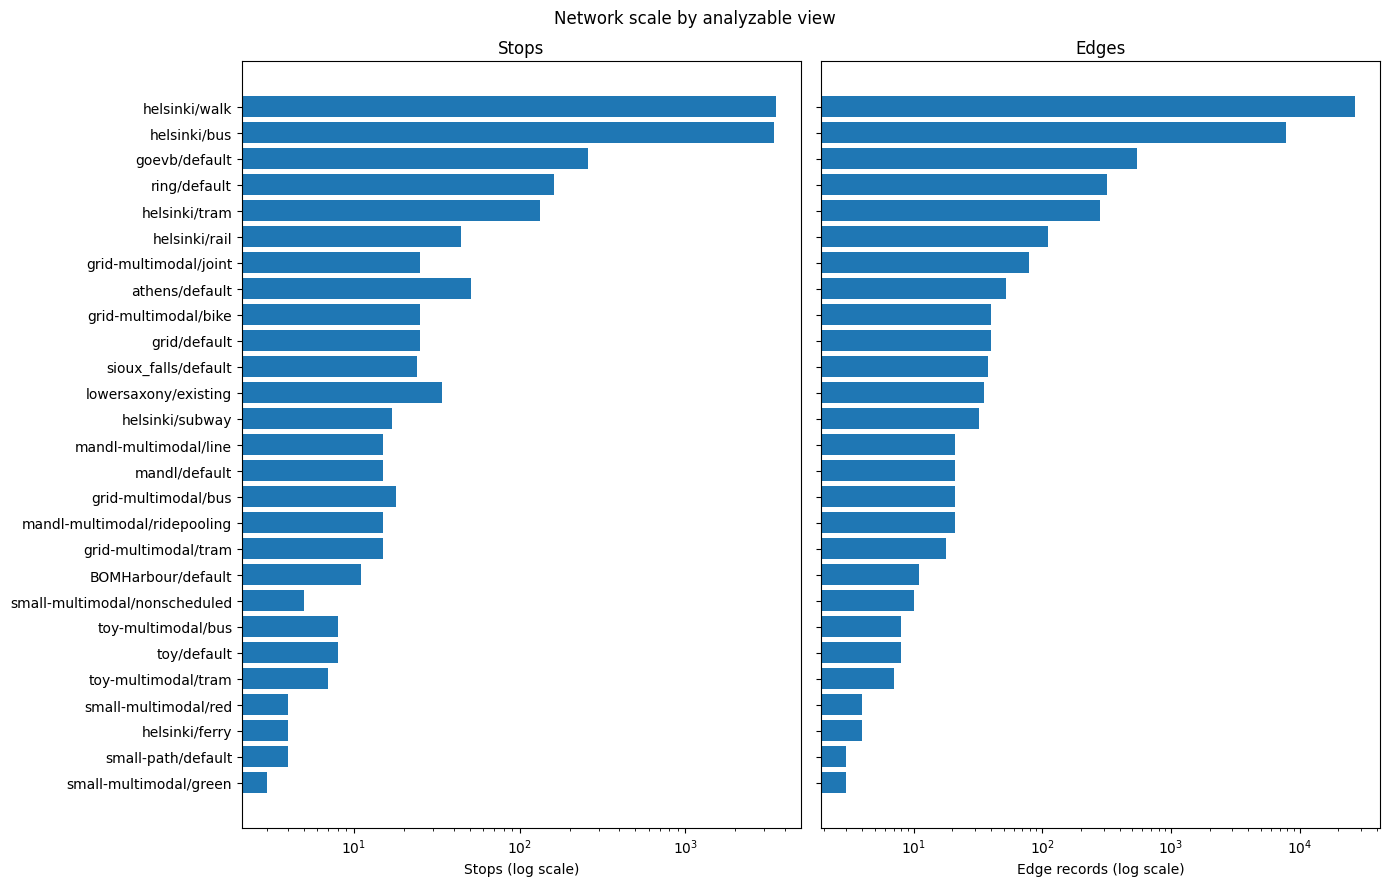

In [11]:
scale = network_summary.sort_values("edge_records", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=True)
y = np.arange(len(scale))
axes[0].barh(y, scale["stops"])
axes[0].set_xscale("log")
axes[0].set_xlabel("Stops (log scale)")
axes[0].set_yticks(y, scale["view"])
axes[0].set_title("Stops")
axes[1].barh(y, scale["edge_records"])
axes[1].set_xscale("log")
axes[1].set_xlabel("Edge records (log scale)")
axes[1].set_title("Edges")
fig.suptitle("Network scale by analyzable view")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "02_network_scale.png", dpi=160, bbox_inches="tight")
plt.show()

### Figure 3 — Network size versus density

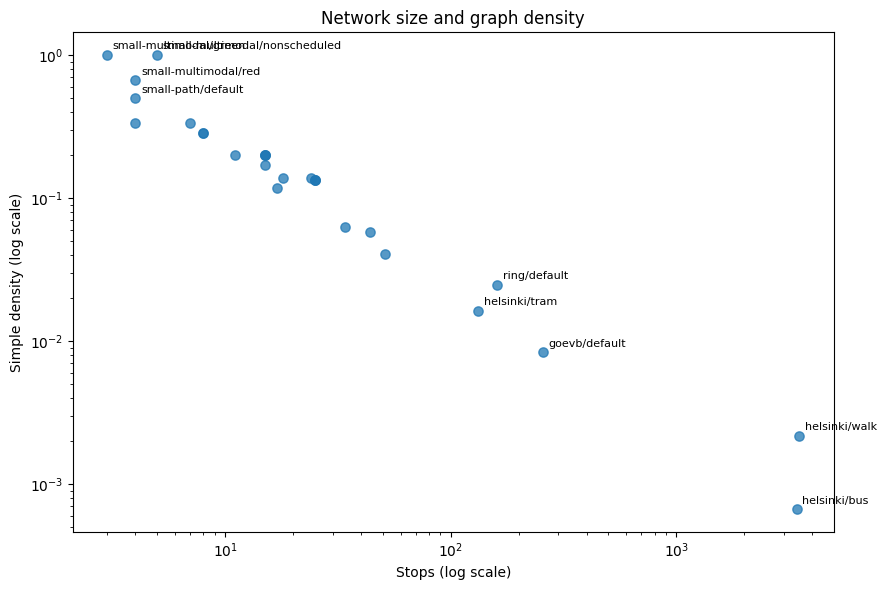

In [12]:
topo = network_summary[(network_summary["stops"] > 1) & (network_summary["simple_density"] > 0)].copy()
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(topo["stops"], topo["simple_density"], s=45, alpha=0.75)
for _, r in topo.iterrows():
    if r["stops"] >= 100 or r["simple_density"] >= 0.5:
        ax.annotate(r["view"], (r["stops"], r["simple_density"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stops (log scale)")
ax.set_ylabel("Simple density (log scale)")
ax.set_title("Network size and graph density")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "03_size_vs_density.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Relate — travel-time structure on the PTN edges

`Edge.giv` stores a **lower** and **upper** travel-time bound, not one observed travel time. To compare datasets with different internal time units, the bounds are converted to minutes using each dataset's effective configuration.

This section stays descriptive: it does not assume that a wider interval is automatically worse.

In [13]:
time_units = network_summary[["view", "time_units_per_minute"]].drop_duplicates()
edge_time = edges.merge(time_units, on="view", how="left")
edge_time["lower_min"] = edge_time["lower"] / edge_time["time_units_per_minute"]
edge_time["upper_min"] = edge_time["upper"] / edge_time["time_units_per_minute"]
edge_time["slack_min"] = edge_time["upper_min"] - edge_time["lower_min"]
edge_time["relative_slack"] = np.where(edge_time["lower_min"] > 0, edge_time["slack_min"] / edge_time["lower_min"], np.nan)

travel_summary = edge_time.groupby("view").agg(
    edges=("edge_id", "size"),
    median_length_km=("length_km", "median"),
    median_lower_min=("lower_min", "median"),
    median_upper_min=("upper_min", "median"),
    median_relative_slack=("relative_slack", "median")
).reset_index()
display(travel_summary.sort_values("median_lower_min"))

,view,edges,median_length_km,median_lower_min,median_upper_min,median_relative_slack
2,goevb/default,548,0.345345,1.00,6.00,5.000000
11,helsinki/subway,32,1.305000,1.00,3.00,2.000000
10,helsinki/rail,110,1.953000,1.00,3.00,2.000000
14,lowersaxony/existing,35,6.513453,1.00,5.00,4.000000
12,helsinki/tram,281,0.299000,1.00,3.00,2.000000
8,helsinki/bus,7768,0.349000,1.00,3.00,2.000000
1,athens/default,52,0.968870,1.55,2.35,0.500000
18,ring/default,320,0.500000,2.00,3.00,0.500000
22,small-multimodal/red,4,12.000000,3.00,3.00,0.125000
26,toy/default,8,12.000000,3.50,5.50,0.366667


### Figure 4 — Median lower and upper travel-time bounds by view

**How it is made:** for every network view, the median lower and upper edge bound are calculated after unit conversion to minutes.

**How to read it:** the horizontal segment is the typical allowed travel-time window for an edge in that view. Comparing the two endpoints is more faithful than collapsing the interval to one number.

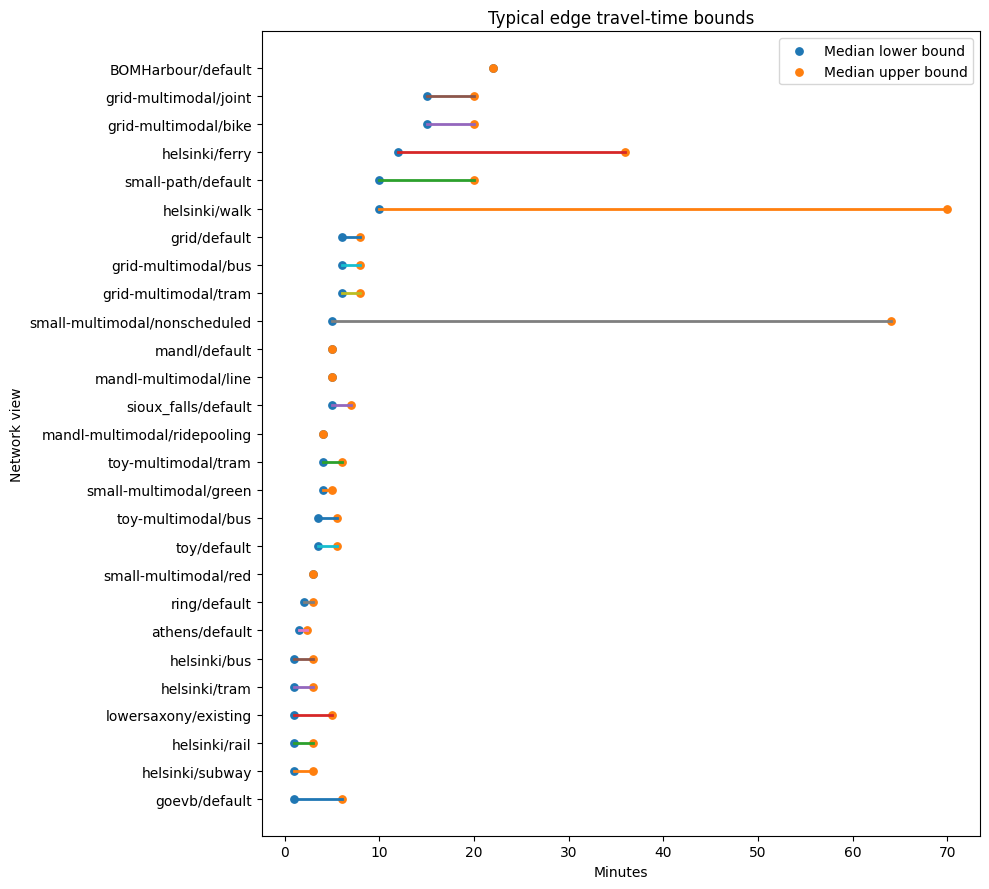

In [14]:
tt = travel_summary.sort_values("median_lower_min")
fig, ax = plt.subplots(figsize=(10, 9))
y = np.arange(len(tt))
for i, r in enumerate(tt.itertuples()):
    ax.plot([r.median_lower_min, r.median_upper_min], [i, i], linewidth=2)
ax.scatter(tt["median_lower_min"], y, label="Median lower bound", s=28)
ax.scatter(tt["median_upper_min"], y, label="Median upper bound", s=28)
ax.set_yticks(y, tt["view"])
ax.set_xlabel("Minutes")
ax.set_ylabel("Network view")
ax.set_title("Typical edge travel-time bounds")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "04_travel_time_bounds.png", dpi=160, bbox_inches="tight")
plt.show()

### Figure 5 — Edge length versus lower travel-time bound

**How it is made:** all positive-length edges are pooled after converting length to kilometres and time to minutes. A transparent scatter is used because the dataset contains many edges.

**How to read it:** this tests whether longer links generally require more minimum travel time. Because multiple networks and transport modes are pooled, the relationship is exploratory rather than causal.

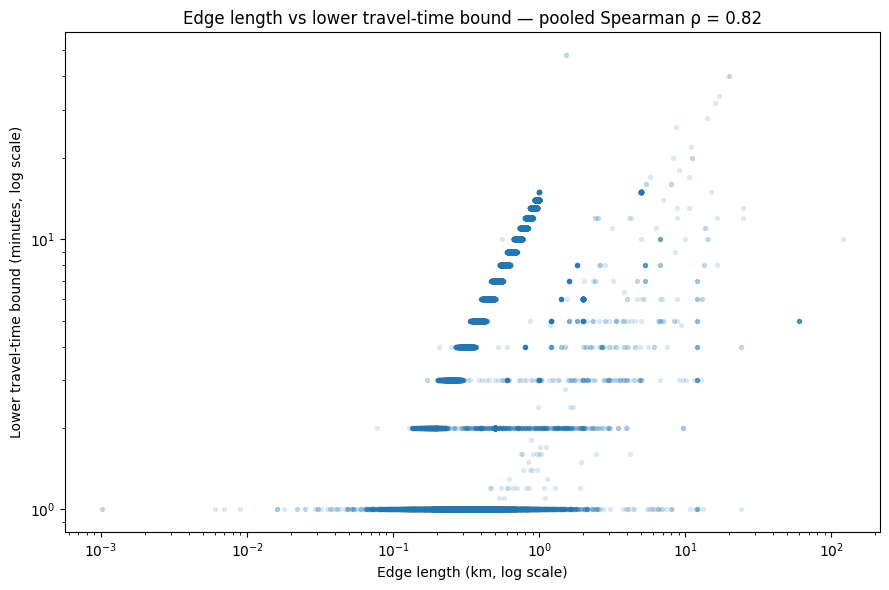

,view,edges,spearman_rho,p_value
0,BOMHarbour/default,11,1.000000,0.000000e+00
3,grid-multimodal/joint,79,1.000000,0.000000e+00
15,small-multimodal/nonscheduled,10,1.000000,6.646897e-64
8,helsinki/walk,26698,0.994249,0.000000e+00
10,mandl-multimodal/line,21,0.992420,9.132813e-19
12,mandl/default,21,0.992420,9.132813e-19
11,mandl-multimodal/ridepooling,21,0.989770,1.560182e-17
14,sioux_falls/default,38,0.984861,5.345948e-29
13,ring/default,320,0.959387,7.830272e-177
5,helsinki/rail,110,0.859143,3.355446e-33


In [15]:
from scipy.stats import spearmanr
rel = edge_time[(edge_time["length_km"] > 0) & (edge_time["lower_min"] > 0)].copy()
rho, pval = spearmanr(rel["length_km"], rel["lower_min"], nan_policy="omit")
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(rel["length_km"], rel["lower_min"], s=8, alpha=0.12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Edge length (km, log scale)")
ax.set_ylabel("Lower travel-time bound (minutes, log scale)")
ax.set_title(f"Edge length vs lower travel-time bound — pooled Spearman ρ = {rho:.2f}")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "05_length_vs_travel_time.png", dpi=160, bbox_inches="tight")
plt.show()

per_view_corr=[]
for view, g in rel.groupby("view"):
    if len(g) >= 5 and g["length_km"].nunique() > 1 and g["lower_min"].nunique() > 1:
        r, p = spearmanr(g["length_km"], g["lower_min"])
        per_view_corr.append([view, len(g), r, p])
per_view_corr = pd.DataFrame(per_view_corr, columns=["view", "edges", "spearman_rho", "p_value"]).sort_values("spearman_rho", ascending=False)
display(per_view_corr)

### Figure 6 — Relative travel-time flexibility by view

**How it is made:** for each edge, `(upper - lower) / lower` measures the width of the allowed interval relative to its lower bound. The chart shows the median by view.

**How to read it:** values near zero indicate tightly specified edge times; larger values indicate wider modelled flexibility. It should not be interpreted as observed delay variability.

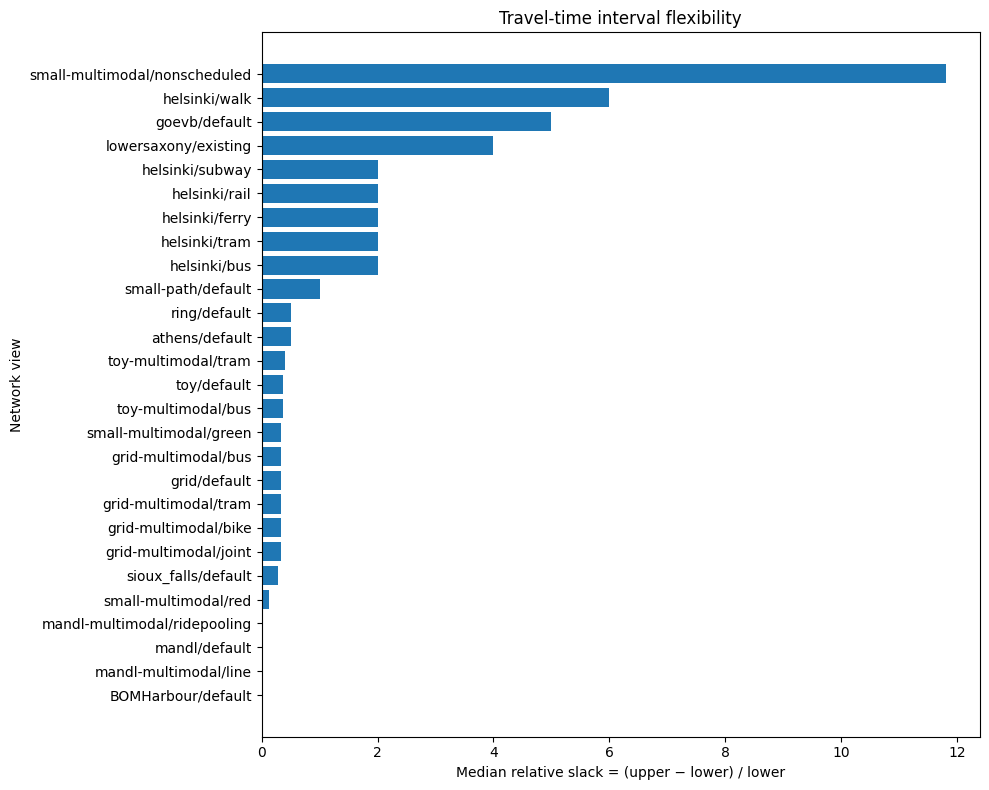

In [16]:
slack = travel_summary.dropna(subset=["median_relative_slack"]).sort_values("median_relative_slack")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(slack["view"], slack["median_relative_slack"])
ax.set_xlabel("Median relative slack = (upper − lower) / lower")
ax.set_ylabel("Network view")
ax.set_title("Travel-time interval flexibility")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "06_relative_travel_time_slack.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Relate — demand/load and operational frequency constraints

Where `Load.giv` exists, it records edge load together with lower and upper frequency constraints. This allows a broad check of whether higher-load edges tend to require higher minimum service frequency.

### Figure 7 — Edge load versus lower-frequency requirement

**How it is made:** every positive-load record from all available `Load.giv` files is plotted; load uses a logarithmic x-axis. A per-view Spearman correlation table is shown below.

**How to read it:** an upward pattern is consistent with frequency requirements increasing with modelled passenger load. Dataset-specific correlations matter more than a pooled visual pattern.

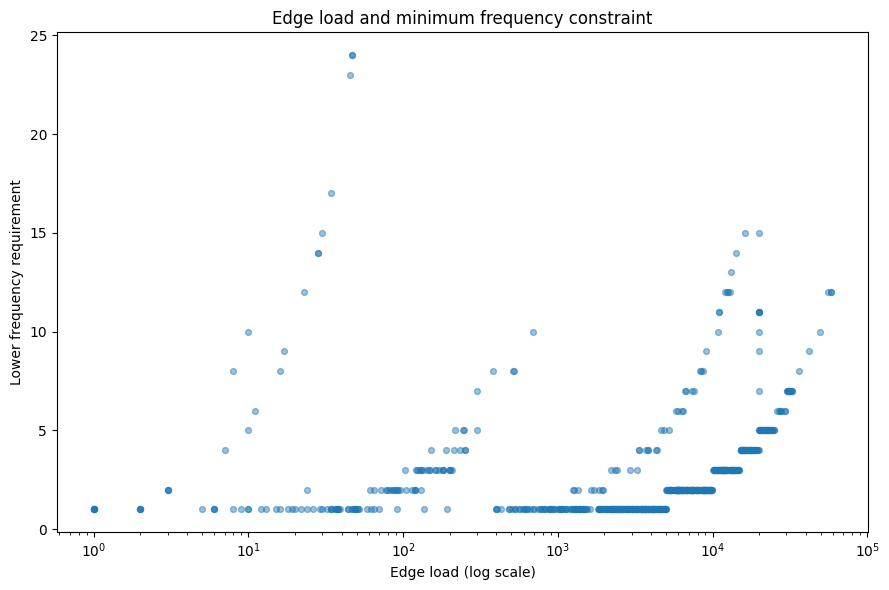

,view,records,spearman_rho,p_value
0,athens/default,52,0.994542,9.410649e-51
2,grid-multimodal/bike,24,0.986696,7.490337e-19
4,grid-multimodal/tram,18,0.973859,1.010342e-11
3,grid-multimodal/bus,21,0.956154,1.383847e-11
1,goevb/default,546,0.950558,1.880897e-278
6,toy/default,8,0.943527,4.313956e-04
5,grid/default,40,0.927376,8.223720e-18


In [17]:
load_rel = edge_loads[(edge_loads["load"] > 0) & (edge_loads["lower_frequency"] >= 0)].copy()
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(load_rel["load"], load_rel["lower_frequency"], s=18, alpha=0.45)
ax.set_xscale("log")
ax.set_xlabel("Edge load (log scale)")
ax.set_ylabel("Lower frequency requirement")
ax.set_title("Edge load and minimum frequency constraint")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "07_load_vs_lower_frequency.png", dpi=160, bbox_inches="tight")
plt.show()

load_corr=[]
for view, g in load_rel.groupby("view"):
    if len(g) >= 5 and g["load"].nunique() > 1 and g["lower_frequency"].nunique() > 1:
        r, p = spearmanr(g["load"], g["lower_frequency"])
        load_corr.append([view, len(g), r, p])
load_corr = pd.DataFrame(load_corr, columns=["view", "records", "spearman_rho", "p_value"]).sort_values("spearman_rho", ascending=False)
display(load_corr)

## 7. Discover — OD-demand concentration

An OD matrix can have the same total demand but a very different spatial concentration. The metric below asks what share of positive recorded demand is carried by the top 10% of positive OD pairs.

### Figure 8 — Demand concentration across OD datasets

**How it is made:** only views with positive OD demand are retained. Higher bars mean a larger share of demand is concentrated in a small subset of OD pairs.

**How to read it:** concentrated demand may motivate different planning questions from diffuse demand, such as trunk-route design versus broad network coverage.

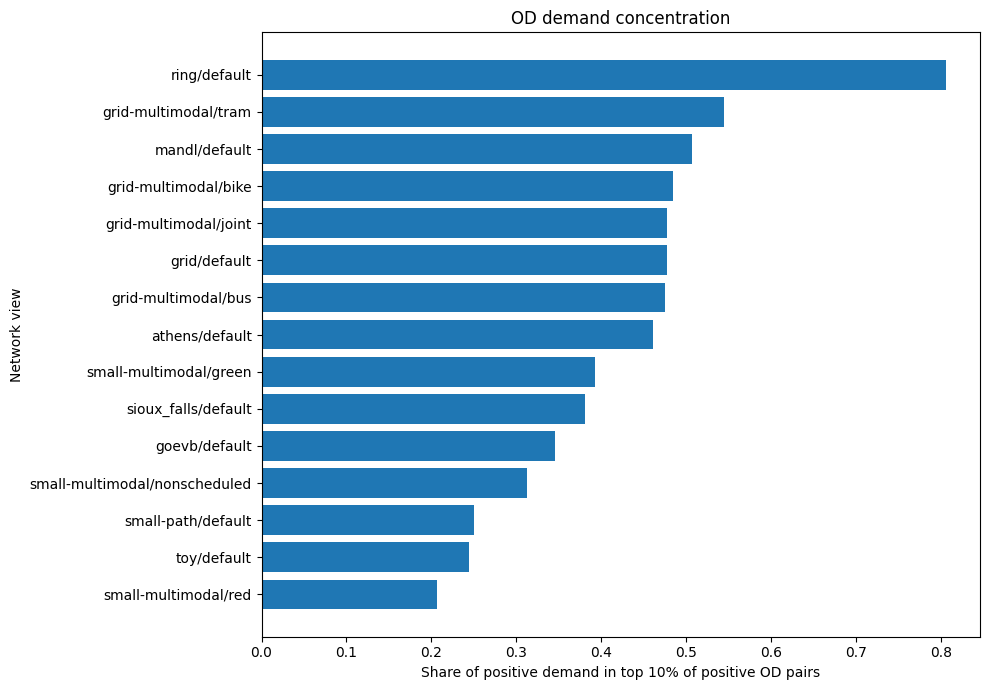

In [18]:
od_plot = od_summary.dropna(subset=["top10pct_positive_pair_share"]).copy()
od_plot = od_plot[od_plot["total_recorded_demand"] > 0].sort_values("top10pct_positive_pair_share")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(od_plot["view"], od_plot["top10pct_positive_pair_share"])
ax.set_xlabel("Share of positive demand in top 10% of positive OD pairs")
ax.set_ylabel("Network view")
ax.set_title("OD demand concentration")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "08_od_demand_concentration.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Infrastructure capacity — an important scope limitation

The phrase “maximum number of vehicles allowed to use a link” maps to the `capacity` field in `Infrastructure-Link.giv`, **not** to the standard PTN `Edge.giv` files. Only multimodal infrastructure datasets provide this field in the uploaded snapshot.

Therefore, capacity can support a focused multimodal/infrastructure question, but it cannot be treated as a universal feature of all 27 PTN views.

In [19]:
infra_frames=[]
for path, df in study.tables.items():
    if path.endswith("Infrastructure-Link.giv"):
        tmp=df.copy()
        tmp["dataset"] = path.split("/")[1]
        tmp["source"] = path
        infra_frames.append(tmp)
infra = pd.concat(infra_frames, ignore_index=True) if infra_frames else pd.DataFrame()

if len(infra):
    capacity_summary = infra.groupby("dataset").agg(
        infrastructure_links=("link_id", "size"),
        unique_capacities=("capacity", "nunique"),
        min_capacity=("capacity", "min"),
        median_capacity=("capacity", "median"),
        max_capacity=("capacity", "max")
    ).reset_index()
    display(capacity_summary)
    display(infra[["dataset", "link_id", "length", "capacity", "modalities", "directions", "source"]])
else:
    print("No Infrastructure-Link.giv files found.")

,dataset,infrastructure_links,unique_capacities,min_capacity,median_capacity,max_capacity
0,grid-multimodal,75,1,100,100.0,100
1,mandl-multimodal,21,1,10000,10000.0,10000
2,small-multimodal,17,1,100,100.0,100
3,toy-multimodal,8,1,100,100.0,100


,dataset,link_id,length,capacity,modalities,directions,source
0,grid-multimodal,1,2.0,100,[tram],[BOTH],datasets/grid-multimodal/basis/Infrastructure-Link.giv
1,grid-multimodal,2,2.0,100,[tram],[BOTH],datasets/grid-multimodal/basis/Infrastructure-Link.giv
2,grid-multimodal,3,2.0,100,[tram],[BOTH],datasets/grid-multimodal/basis/Infrastructure-Link.giv
3,grid-multimodal,4,2.0,100,"[tram, bus]","[BOTH, BOTH]",datasets/grid-multimodal/basis/Infrastructure-Link.giv
4,grid-multimodal,5,2.0,100,[tram],[BOTH],datasets/grid-multimodal/basis/Infrastructure-Link.giv
...,...,...,...,...,...,...,...
116,toy-multimodal,4,1.0,100,"[bus, tram]","[BOTH, BOTH]",datasets/toy-multimodal/basis/Infrastructure-Link.giv
117,toy-multimodal,5,0.8,100,"[bus, tram]","[BOTH, BOTH]",datasets/toy-multimodal/basis/Infrastructure-Link.giv
118,toy-multimodal,6,1.0,100,"[bus, tram]","[BOTH, BOTH]",datasets/toy-multimodal/basis/Infrastructure-Link.giv
119,toy-multimodal,7,1.0,100,"[bus, tram]","[BOTH, BOTH]",datasets/toy-multimodal/basis/Infrastructure-Link.giv


## 9. Outliers and special cases worth checking before modelling

In [20]:
edge_outliers = edge_time.assign(
    lower_q=edge_time.groupby("view")["lower_min"].transform(lambda s: s.quantile(0.99)),
    length_q=edge_time.groupby("view")["length_km"].transform(lambda s: s.quantile(0.99))
)
edge_outliers = edge_outliers[(edge_outliers["lower_min"] >= edge_outliers["lower_q"]) | (edge_outliers["length_km"] >= edge_outliers["length_q"])]
edge_outliers = edge_outliers[["view", "edge_id", "length_km", "lower_min", "upper_min", "relative_slack", "source", "_source_line"]].sort_values(["view", "lower_min"], ascending=[True, False])
display(edge_outliers)

,view,edge_id,length_km,lower_min,upper_min,relative_slack,source,_source_line
55,BOMHarbour/default,4,20.00000,40.0,40.0,0.000000,datasets/BOMHarbour/basis/Edge.giv,5
62,BOMHarbour/default,11,20.00000,40.0,40.0,0.000000,datasets/BOMHarbour/basis/Edge.giv,12
48,athens/default,49,3.79574,6.4,9.6,0.500000,datasets/athens/basis/Edge.giv,51
50,athens/default,51,9.28612,4.8,7.2,0.500000,datasets/athens/basis/Edge.giv,53
455,goevb/default,393,0.55539,10.0,15.0,0.500000,datasets/goevb/basis/Edge.giv,394
...,...,...,...,...,...,...,...,...
36180,toy/default,3,12.00000,4.0,5.0,0.250000,datasets/toy/basis/Edge.giv,4
36184,toy/default,7,12.00000,4.0,6.0,0.500000,datasets/toy/basis/Edge.giv,8
36179,toy/default,2,12.00000,3.0,4.0,0.333333,datasets/toy/basis/Edge.giv,3
36181,toy/default,4,12.00000,3.0,9.0,2.000000,datasets/toy/basis/Edge.giv,5


## 10. RQ Back up

1. Linear Programming — Determining service frequencies for each route to minimize total operating costs while satisfying minimum and maximum frequency requirements for all route segments.

2. Non-linear Programming — Allocating service frequencies to minimize congestion while meeting baseline passenger demand.

## 11. Reuse outputs

All generated tables and figures are written to the `OUTPUT_ROOT` printed in Section 1. Because `eda_tools.Study` keeps generated files outside the scanned source root, this is a sibling folder named `<project-folder>_results/`.

The two most important path-audit files are:

- `directory_tree_full.txt` — every project directory shown in Section 1.1.
- `data_file_registry.csv` — every file under `datasets/` with relative and absolute paths.

The notebook also regenerates source-aware OpenLinTim audit tables under `tables/`, including `view_registry.csv`, `file_manifest.csv`, `table_profile.csv`, and `quality_issues.csv`.


In [21]:
generated = sorted([
    p.relative_to(OUTPUT_ROOT).as_posix()
    for p in OUTPUT_ROOT.rglob("*")
    if p.is_file()
])
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Generated files:")
print("\n".join(generated))


OUTPUT_ROOT: C:\Users\liang\OneDrive\Desktop\openlintim_results
Generated files:
audit/directory_tree.txt
audit/file_manifest.json
audit/run_metadata.json
data_file_registry.csv
directory_tree_full.txt
figures/01_core_data_availability.png
figures/02_network_scale.png
figures/03_size_vs_density.png
figures/04_travel_time_bounds.png
figures/05_length_vs_travel_time.png
figures/06_relative_travel_time_slack.png
figures/07_load_vs_lower_frequency.png
figures/08_od_demand_concentration.png
tables/column_profile.csv
tables/config_includes.csv
tables/configured_paths.csv
tables/demand_points.csv
tables/edge_loads.csv
tables/edges_enriched.csv
tables/effective_config.csv
tables/file_manifest.csv
tables/infrastructure_od_summary.csv
tables/line_pool_summary.csv
tables/modality_overlap.csv
tables/network_summary.csv
tables/node_metrics.csv
tables/od_accessibility.csv
tables/od_summary.csv
tables/parse_issues.csv
tables/quality_issues.csv
tables/table_profile.csv
tables/view_registry.csv
